In [16]:
import pandas as pd

In [17]:
# No missing values
# No Duplicate rows
# Handle correct Data types

#Ensure the correct encoding is used to read the CSV file
df = pd.read_csv('../data/Raw-Superstore.csv', encoding='cp1252')

# Checking Order Dates Format
print("Sample Order Dates (Before Conversion)")
print(df['Order Date'].head())
print(df['Order Date'].tail())

# Checking Ship Dates Format
print("Sample Ship Dates (Before Conversion)")
print(df['Ship Date'].head())
print(df['Ship Date'].tail())

# Create a copy of the DataFrame
df_copy = df.copy() 

# Convert 'Order Date' to datetime format
df_copy['Order Date'] = pd.to_datetime(df_copy['Order Date'], format='%m/%d/%Y', errors='coerce') 
print(f'Number of Not Available values in Order Dates : {df_copy['Order Date'].isna().sum()}')

# Convert 'Ship Date' to datetime format
df_copy['Ship Date'] = pd.to_datetime(df_copy['Ship Date'], format='%m/%d/%Y', errors='coerce') 
print(f'Number of Not Available values in Ship Dates : {df_copy['Ship Date'].isna().sum()}')

# Handle this case
# if df_copy['Order Date'].isna().sum() > 0 or df_copy['Ship Date'].isna().sum() > 0: 
#     pass

# Convert 'Order Date' to datetime format
df['Order Date'] = pd.to_datetime(df['Order Date'], format='%m/%d/%Y') 
# Convert 'Ship Date' to datetime format
df['Ship Date'] = pd.to_datetime(df['Ship Date'], format='%m/%d/%Y') 


Sample Order Dates (Before Conversion)
0     11/8/2016
1     11/8/2016
2     6/12/2016
3    10/11/2015
4    10/11/2015
Name: Order Date, dtype: str
9989    1/21/2014
9990    2/26/2017
9991    2/26/2017
9992    2/26/2017
9993     5/4/2017
Name: Order Date, dtype: str
Sample Ship Dates (Before Conversion)
0    11/11/2016
1    11/11/2016
2     6/16/2016
3    10/18/2015
4    10/18/2015
Name: Ship Date, dtype: str
9989    1/23/2014
9990     3/3/2017
9991     3/3/2017
9992     3/3/2017
9993     5/9/2017
Name: Ship Date, dtype: str
Number of Not Available values in Order Dates : 0
Number of Not Available values in Ship Dates : 0


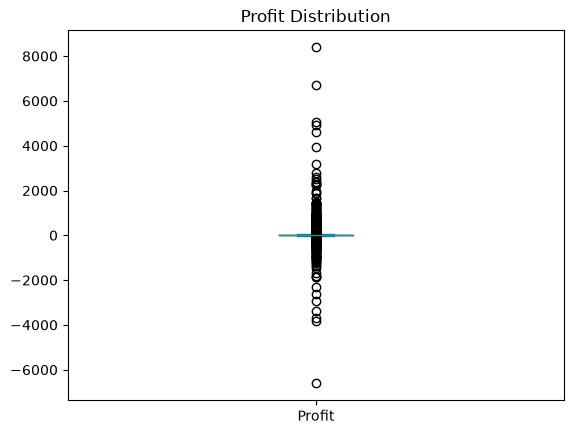

In [18]:
#Outlier Detection and Handling
import matplotlib.pyplot as plt

df['Profit'].plot(kind='box', title='Profit Distribution')
plt.show()

In [19]:
print(df[df["Profit"] > 6000] [['Profit', 'Sales', 'Discount', 'Quantity', 'Product Name']])

# capped_Profit = df[df["Profit"] > 1000]
# capped_Profit['Profit'].plot(kind='box', title='Capped Profit Distribution')

         Profit     Sales  Discount  Quantity  \
6826  8399.9760  17499.95       0.0         5   
8153  6719.9808  13999.96       0.0         4   

                               Product Name  
6826  Canon imageCLASS 2200 Advanced Copier  
8153  Canon imageCLASS 2200 Advanced Copier  


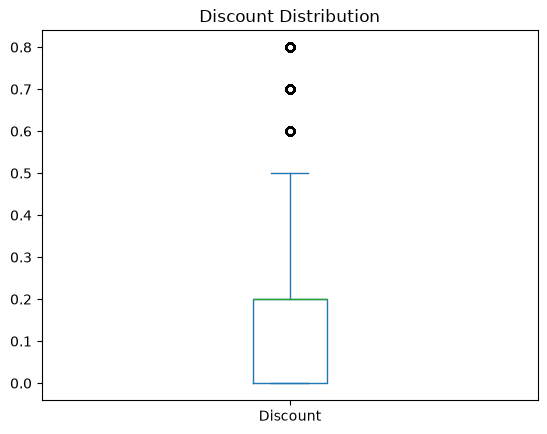

In [20]:
df['Discount'].plot(kind='box', title='Discount Distribution')
plt.show()

In [21]:
print(df.loc[df['Discount'] > 0.7, ['Order ID', 'Sales', 'Profit', 'Discount', 'Quantity']])

            Order ID    Sales    Profit  Discount  Quantity
14    US-2015-118983   68.810 -123.8580       0.8         5
15    US-2015-118983    2.544   -3.8160       0.8         3
75    US-2017-118038    1.248   -1.9344       0.8         3
101   CA-2016-158568    1.788   -3.0396       0.8         3
169   CA-2014-139892  177.980 -453.8490       0.8         5
...              ...      ...       ...       ...       ...
9794  CA-2014-127166   18.240  -31.0080       0.8         3
9795  CA-2016-125920    3.798   -5.8869       0.8         3
9808  CA-2017-145093    2.112   -3.3792       0.8         2
9835  CA-2016-126627   16.392  -26.2272       0.8         2
9920  CA-2016-149272   22.386  -35.8176       0.8         7

[300 rows x 5 columns]


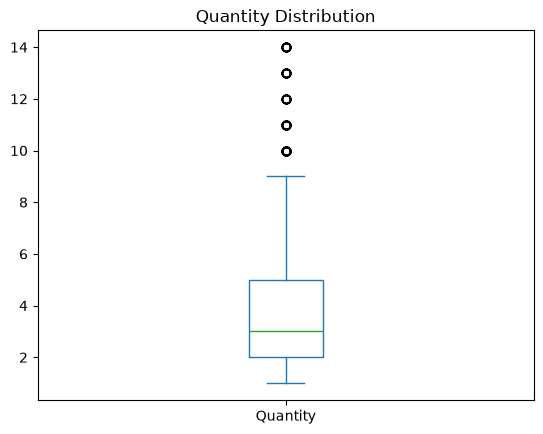

In [22]:
df['Quantity'].plot(kind='box', title='Quantity Distribution')
plt.show()

In [23]:
print(df.loc[df['Quantity'] > 9, ['Order ID', 'Sales', 'Profit', 'Discount', 'Quantity']])

            Order ID     Sales    Profit  Discount  Quantity
113   CA-2014-115259    40.096   14.5348       0.2        14
139   CA-2016-145583    43.120   20.6976       0.0        14
147   CA-2016-114489   384.450  103.8015       0.0        11
251   CA-2016-145625  3347.370  636.0003       0.0        13
329   US-2016-141544   100.240   33.8310       0.2        10
...              ...       ...       ...       ...       ...
9882  CA-2014-153927   272.610   98.1396       0.0        13
9895  CA-2014-115049   153.824   38.4560       0.2        11
9941  CA-2017-164028   223.580   87.1962       0.0        14
9979  US-2016-103674   437.472  153.1152       0.2        14
9984  CA-2015-100251    31.500   15.1200       0.0        10

[170 rows x 5 columns]


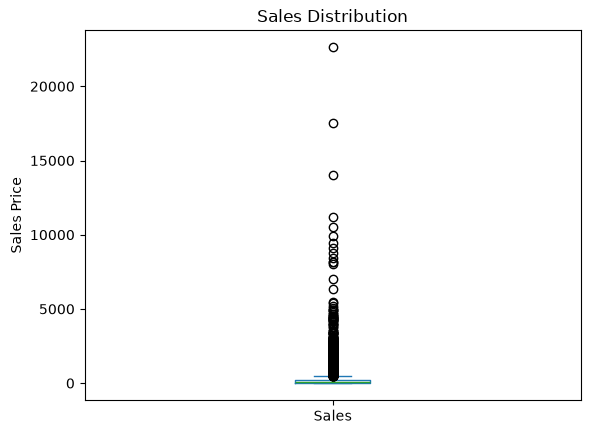

In [24]:
df['Sales'].plot(kind='box', title='Sales Distribution')
plt.ylabel("Sales Price")
plt.show()

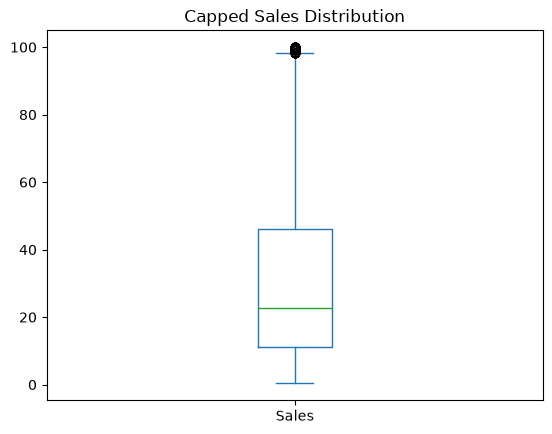

In [25]:
# print(df.loc[df['Sales'] > 1000, ['Order ID', 'Sales', 'Profit', 'Discount', 'Quantity']])
capped = df.loc[df['Sales'] <= 100, ['Order ID', 'Sales', 'Profit', 'Discount', 'Quantity']]

capped['Sales'].plot(kind='box', title='Capped Sales Distribution')
plt.show()

In [26]:
# Create new Calculated Columns and Performing basic feature engineering
# 1st column Shipping Delay
df['Shipping Delay'] = df['Ship Date'] - df['Order Date']
print(df['Shipping Delay'])

0      3 days
1      3 days
2      4 days
3      7 days
4      7 days
        ...  
9989   2 days
9990   5 days
9991   5 days
9992   5 days
9993   5 days
Name: Shipping Delay, Length: 9994, dtype: timedelta64[us]


In [27]:
# 2nd Extracting Order Year from Order Date
df['Order Year'] = df['Order Date'].dt.year
# 3rd Extracting Order Month from Order Date
df['Order Month'] = df['Order Date'].dt.month

In [28]:
# 4th Aggregate Orders per Customer
df['Order Count'] =  df.groupby('Customer ID')['Order ID'].transform('count')

In [29]:
print((df['Customer ID'] == 'CG-12520').sum())

5


In [30]:
#Creating new cleaned csv file in data folder
df.to_csv("../data/Cleaned-Superstore.csv", index=False)
